# Análise Exploratória de Dados - Dataset Tips

Este projeto tem como objetivo analisar o comportamento de gorjetas em um restaurante, utilizando o dataset `tips` do Seaborn.

Serão respondidas perguntas como:

- Quais os valores médios de gorjeta?
- Existe relação entre o valor da conta e a gorjeta?
- Há diferença entre os turnos (Almoço/Jantar)?
- Quais dias geram maior retorno em gorjetas?



# -----------------------------
# Importação de bibliotecas
# -----------------------------

In [35]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# Carregamento e preparação dos dados
# -----------------------------

In [38]:
tips = sns.load_dataset('tips')
tips = tips.rename(columns={
    'total_bill': 'valor_conta',
    'tip': 'gorjeta',
    'sex': 'sexo',
    'smoker': 'fumante',
    'day': 'dia',
    'time': 'turno',
    'size': 'quantidade_pessoas'
})

tips['sexo'] = tips['sexo'].map({'Female': 'Feminino', 'Male': 'Masculino'})
tips['fumante'] = tips['fumante'].map({'No': 'Não', 'Yes': 'Sim'})
tips['dia'] = tips['dia'].map({'Sun': 'Domingo', 'Sat': 'Sábado', 'Thur': 'Quinta-feira', 'Fri': 'Sexta-feira'})
tips['turno'] = tips['turno'].map({'Dinner': 'Jantar', 'Lunch': 'Almoço'})

# -----------------------------
# Estatísticas descritivas
# -----------------------------

In [41]:

descricao = tips.describe()
descricao = descricao.rename(columns={
    'valor_conta': 'Valor da Conta',
    'gorjeta': 'Gorjeta',
    'quantidade_pessoas': 'Quantidade de Pessoas'
})
descricao.index = descricao.index.map({
    'count': 'Contagem',
    'mean': 'Média',
    'std': 'Desvio Padrão',
    'min': 'Mínimo',
    '25%': '1º Quartil (25%)',
    '50%': 'Mediana (50%)',
    '75%': '3º Quartil (75%)',
    'max': 'Máximo'
})


# Formatando os valores monetários e inteiros

In [44]:
descricao['Valor da Conta'] = descricao['Valor da Conta'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'))
descricao['Gorjeta'] = descricao['Gorjeta'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'))
descricao['Quantidade de Pessoas'] = descricao['Quantidade de Pessoas'].apply(lambda x: f'{x:.0f}' if x.is_integer() else f'{x:.2f}')
descricao

,Valor da Conta,Gorjeta,Quantidade de Pessoas
Contagem,"R$ 244,00","R$ 244,00",244
Média,"R$ 19,79","R$ 3,00",2.57
Desvio Padrão,"R$ 8,90","R$ 1,38",0.95
Mínimo,"R$ 3,07","R$ 1,00",1
1º Quartil (25%),"R$ 13,35","R$ 2,00",2
Mediana (50%),"R$ 17,80","R$ 2,90",2
3º Quartil (75%),"R$ 24,13","R$ 3,56",3
Máximo,"R$ 50,81","R$ 10,00",6


# -----------------------------
# Gráfico: Histograma dos valores da conta
# -----------------------------

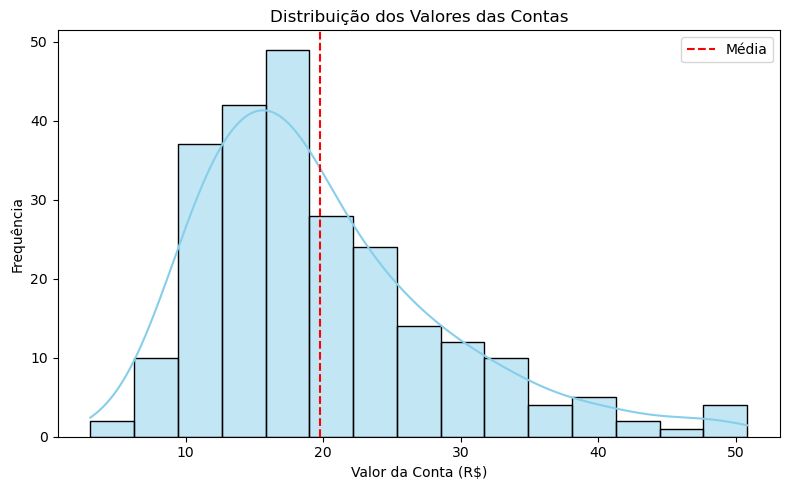

In [47]:

plt.figure(figsize=(8, 5))
sns.histplot(tips['valor_conta'], kde=True, bins=15, color='skyblue', edgecolor='black')
plt.axvline(tips['valor_conta'].mean(), color='red', linestyle='--', label='Média')
plt.title('Distribuição dos Valores das Contas')
plt.xlabel('Valor da Conta (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Gráfico: Média da gorjeta por faixa de valor da conta
# -----------------------------

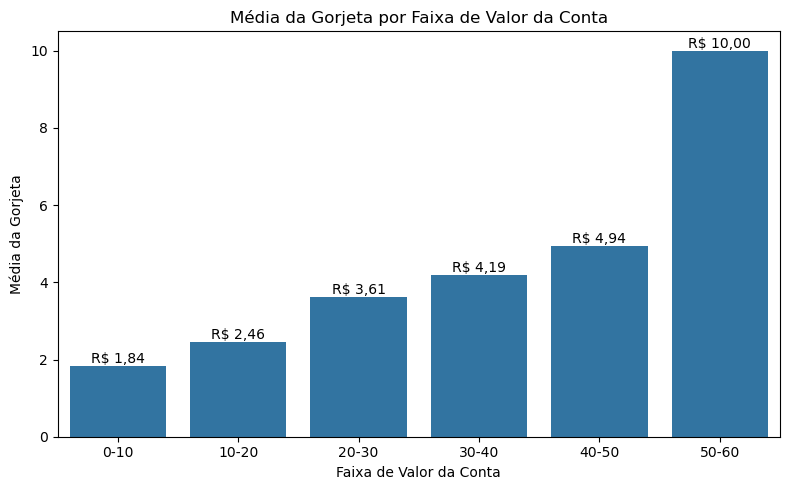

In [50]:

bins = [0, 10, 20, 30, 40, 50, 60]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60']
tips['faixa_valor'] = pd.cut(tips['valor_conta'], bins=bins, labels=labels)

media_gorjetas = tips.groupby('faixa_valor', observed=False)['gorjeta'].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='faixa_valor', y='gorjeta', data=media_gorjetas)
ax.bar_label(ax.containers[0], labels=[f'R$ {v:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.') for v in media_gorjetas['gorjeta']])
plt.title('Média da Gorjeta por Faixa de Valor da Conta')
plt.xlabel('Faixa de Valor da Conta')
plt.ylabel('Média da Gorjeta')
plt.tight_layout()
plt.show()


# -----------------------------
# Gráfico: Média da gorjeta por dia
# -----------------------------

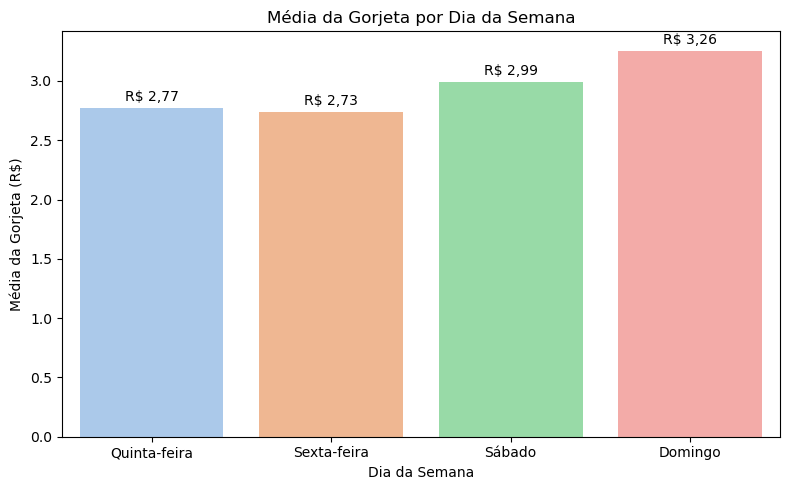

In [66]:

media_gorjetas_dia = tips.groupby('dia', observed=False)['gorjeta'].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='dia', y='gorjeta', data=media_gorjetas_dia, hue='dia', palette='pastel', legend=False)
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                xytext=(0, 8), textcoords='offset points', ha='center', va='center')
plt.title('Média da Gorjeta por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Média da Gorjeta (R$)')
plt.tight_layout()
plt.show()


# -----------------------------
# Gráfico: Média da gorjeta por turno
# -----------------------------

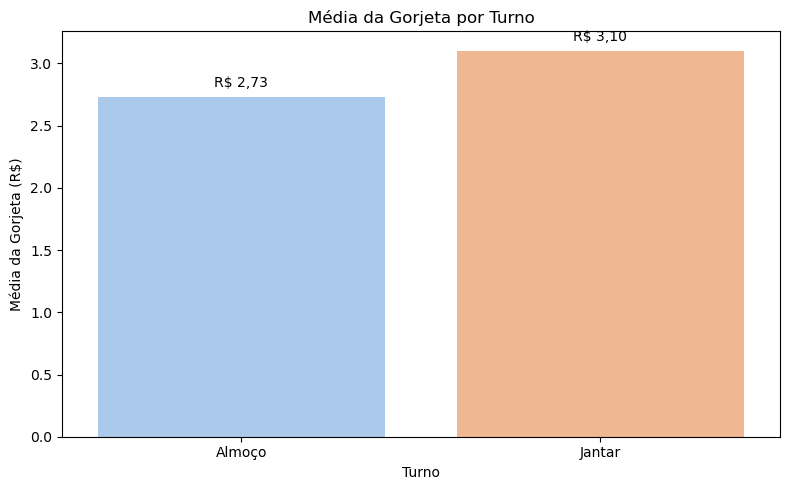

In [68]:

media_gorjetas_turno = tips.groupby('turno', observed=True)['gorjeta'].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='turno', y='gorjeta', data=media_gorjetas_turno, hue='turno', palette='pastel', legend=False)
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom')
plt.title('Média da Gorjeta por Turno')
plt.xlabel('Turno')
plt.ylabel('Média da Gorjeta (R$)')
plt.tight_layout()
plt.show()

# -----------------------------
# Conclusão
# -----------------------------

# - A gorjeta média é de aproximadamente R$ 3,00.
# - Existe relação positiva entre o valor da conta e a gorjeta.
# - O turno da noite (Jantar) tende a gerar gorjetas maiores.
# - Domingo é o dia com maior média de gorjetas entre os dias analisados.